# Module 5 — Dynamic Hedging of Impermanent Loss

In [62]:
import requests
import datetime
import time
import matplotlib.patches as mpatches
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Task 5.1 — Theoretical Framework
## 5.1.1 — LP Payoff Shape and the Short Gamma Interpretation

> ### Instructions : Students must plot the payoff of the LP position as a function of terminal ETH price, for each of the five positions defined in Module 4, ignoring fee income. 
> ### The plot must cover a price range from 0.5 to 1.5 times the entry price.

####  Here are the five postiions defined in Module 4 :

| Position | Price Range | Character |
| :--- | :--- | :--- |
| **P1** | ±0.1% | Ultra-narrow, market-maker style |
| **P2** | ±0.5% | Narrow, active LP style |
| **P3** | ±2% | Medium, typical retail LP |
| **P4** | ±10% | Wide, passive LP |
| **P5** | Full range | V2-equivalent, fully passive |

According to module 4, "students will define five synthetic representative positions, all entered at the first daily snapshot
block of the study window, all exited at the last daily snapshot block, and all sized at $100,000
USD equivalent at the time of entry. **The five positions are defined by their range width, centred on the current tick at entry.**"

Then we are always in the case where: $$p_0 \in ]p_a, p_b[$$

### The value of LP position is split in three categories:

##### --> Case 1: $p < p_a$
$$V(p) = L \left( \frac{1}{\sqrt{p_a}} - \frac{1}{\sqrt{p_b}} \right) p$$

##### --> Case 2: $p \in [p_a, p_b]$
$$V(p) = L \left( 2\sqrt{p} - \frac{p}{\sqrt{p_b}} - \sqrt{p_a} \right)$$

##### --> Case 3: $p > p_b$
$$V(p) = L(\sqrt{p_b} - \sqrt{p_a})$$

#### *NB : we take a random initial price here, in order to be able to compare charts with same x axis*

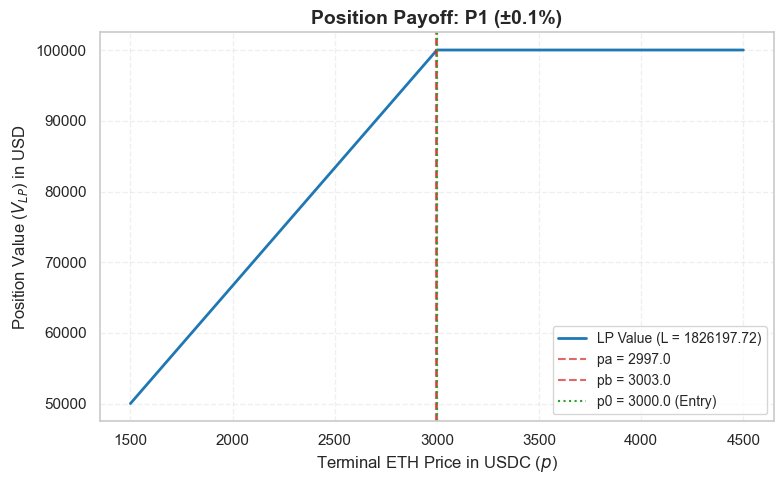

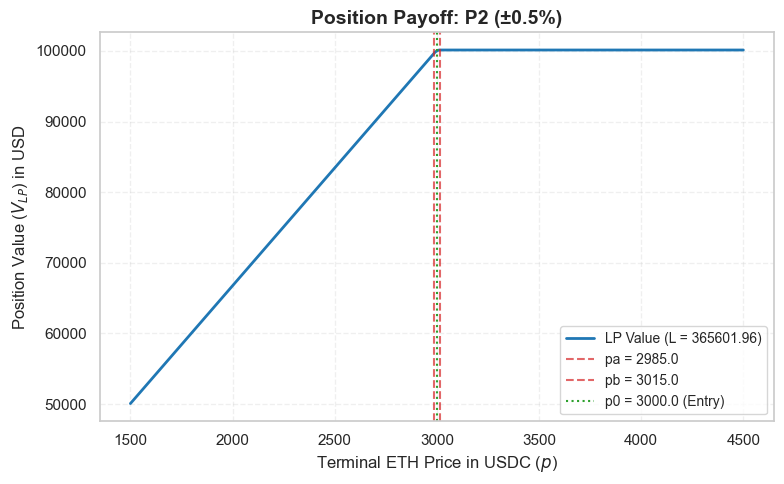

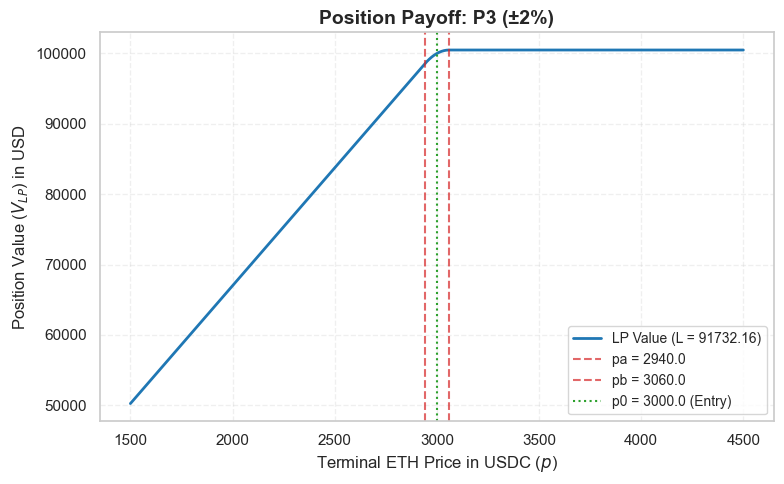

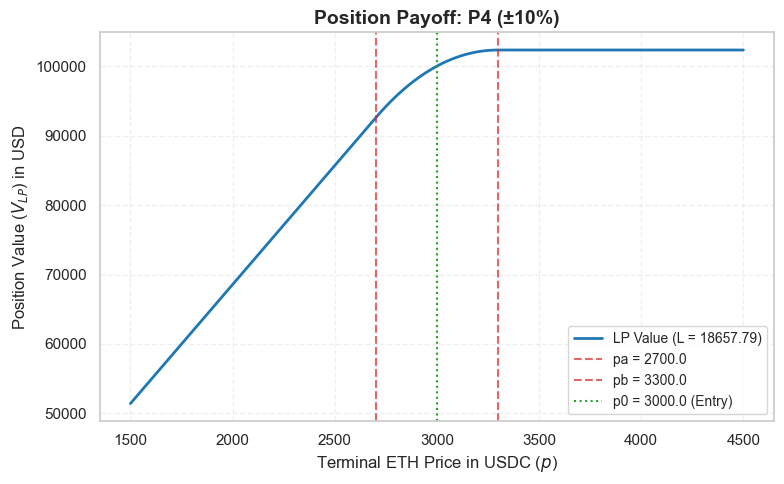

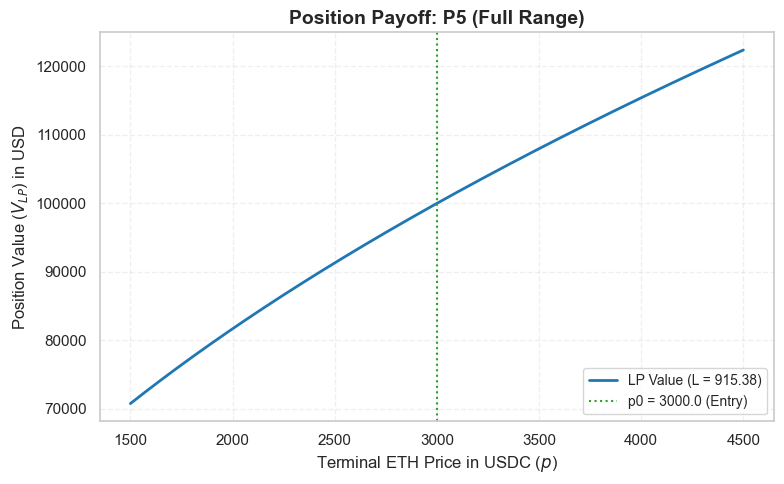

In [63]:
p0 = 3000.0  # Entry Price (ETH/USDC) / see the NB above the cell
V0 = 100000.0 # Initial Notional invested in USD according to the instructions
p_range = np.linspace(0.5 * p0, 1.5 * p0, 1000) # Range for plotting: from 0.5x to 1.5x of entry price according to the instructions

# 5 Synthetic Positions (from Module 4)
positions = {
    "P1 (±0.1%)": (p0 * 0.999, p0 * 1.001),
    "P2 (±0.5%)": (p0 * 0.995, p0 * 1.005),
    "P3 (±2%)":   (p0 * 0.98,  p0 * 1.02),
    "P4 (±10%)":  (p0 * 0.90,  p0 * 1.10),
    "P5 (Full Range)": (1e-8, 1e8)
}

def calculate_v_lp(p_array, pa, pb, L):
    v_lp = np.zeros_like(p_array)

    for i, p in enumerate(p_array):
        if p < pa:
            # Below range: Position is 100% ETH
            x_max = L * ((1 / np.sqrt(pa)) - (1 / np.sqrt(pb)))
            v_lp[i] = x_max * p
        elif p > pb:
            # Above range: Position is 100% USDC
            y_max = L * (np.sqrt(pb) - np.sqrt(pa))
            v_lp[i] = y_max
        else:
            # In range: Position is a mix of ETH and USDC
            v_lp[i] = L * (2 * np.sqrt(p) - (p / np.sqrt(pb)) - np.sqrt(pa))
    return v_lp

for name, (pa, pb) in positions.items():
    # Determination of liquidity constant L (see the NB below this cell)
    L = V0 / (2 * np.sqrt(p0) - (p0 / np.sqrt(pb)) - np.sqrt(pa))

    v_lp = calculate_v_lp(p_range, pa, pb, L)
    
    plt.figure(figsize=(8, 5))
    plt.plot(p_range, v_lp, label=f"LP Value (L = {L:.2f})", color="#1f77b4", linewidth=2)
    
    # Mark price boundaries (except for Full Range to keep plot readable)
    if name != "P5 (Full Range)":
        plt.axvline(x=pa, color='#d62728', linestyle='--', alpha=0.7, label=f"pa = {pa:.1f}")
        plt.axvline(x=pb, color='#d62728', linestyle='--', alpha=0.7, label=f"pb = {pb:.1f}")
    
    # Mark entry price
    plt.axvline(x=p0, color='#2ca02c', linestyle=':', label=f"p0 = {p0:.1f} (Entry)")
    
    plt.title(f"Position Payoff: {name}", fontsize=14, fontweight='bold')
    plt.xlabel("Terminal ETH Price in USDC ($p$)", fontsize=12)
    plt.ylabel("Position Value ($V_{LP}$) in USD", fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    
    plt.savefig(f"Images/payoff_{name}.png", dpi=300)
    
    plt.show()

### --> *NB: Understanding Liquidity ($L$)*
#### I first didn't understand why L value was changing since it was the global pool liquidity in my mind. Than I asked Gemini for explanation :

In this project, **$L$ is a constant** representing the "depth" of the specific position. It should not be confused with the global pool liquidity.

##### 1. Why does $L$ change between P1 and P5?
Since we fix the **Initial Value at \$100,000** for all strategies, $L$ must adjust to compensate for the width of the price range $[p_a, p_b]$:

$$L = \frac{100,000}{2\sqrt{p_0} - \frac{p_0}{\sqrt{p_b}} - \sqrt{p_a}}$$

* **P1 (Ultra-narrow):** The price range is tiny, so **$L$ is massive**. We have high "Capital Efficiency": the \$100k creates a huge depth over a small area, yielding high fees but high Gamma risk.
* **P5 (Full range):** The capital is spread thin across all prices, so **$L$ is small**. We earn fewer fees, but our position is much more stable.

##### 2. Key Takeaway
$L$ measures the **leverage on fee collection**. It is a fixed parameter for each simulation, derived directly from two things: the **initial capital** and the **chosen range width**.

---

> ### Instructions : Students must plot and comment on the payoff shape and its similarity to well-known option payoffs.

 - Payoff shape :
   - P1 : We can see here that this situation makes the transition from 100% ETH to 100% USDC almost instantly. Then, and we will discuss this point right after this cell, the value of L is huge since the liquidity has to be provided in a very small area, then gamma has to be big, which is the case when L is large;
   - For the others cases of module 4, the shape is quite the same, with a larger zone in the middle, corresponding to a lower L value.

    
- Financial parallel : We've seen in the lecture that these situations are **short put position** but with something else in the interval $[pa,pb]$. A representation of this classical option payoffs is given after this cell.

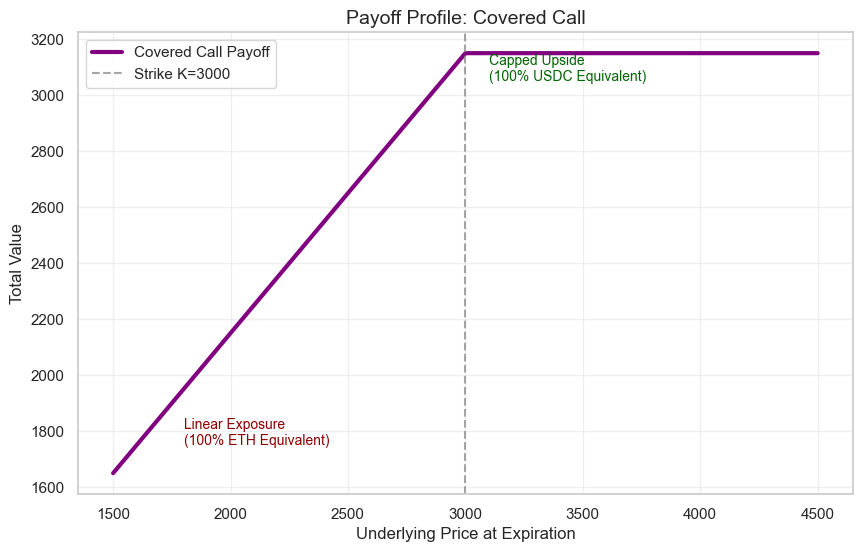

In [64]:
def plot_covered_call(strike=3000, premium=150, current_price=3000):
    # Price range (0.5x to 1.5x the initial price)
    price_range = np.linspace(current_price * 0.5, current_price * 1.5, 1000)
    
    # Value of the underlying asset (Long Asset)
    asset_value = price_range
    
    # Short Call Payoff
    short_call_payoff = premium - np.maximum(price_range - strike, 0)
    
    # Total Covered Call Payoff
    covered_call_payoff = asset_value + short_call_payoff
    
    plt.figure(figsize=(10, 6))
    plt.plot(price_range, covered_call_payoff, label='Covered Call Payoff', color='purple', linewidth=3)
    plt.axvline(strike, color='gray', linestyle='--', alpha=0.7, label=f'Strike K={strike}')
    plt.title('Payoff Profile: Covered Call', fontsize=14)
    plt.xlabel('Underlying Price at Expiration', fontsize=12)
    plt.ylabel('Total Value', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    
    # Annotations to bridge with Uniswap V3
    plt.text(current_price * 0.6, covered_call_payoff.min() + 100, 
             'Linear Exposure\n(100% ETH Equivalent)', color='darkred', fontsize=10)
    
    plt.text(strike + 100, covered_call_payoff.max() - 100, 
             'Capped Upside\n(100% USDC Equivalent)', color='darkgreen', fontsize=10)

    plt.savefig("Images/Payoff_Profile_Covered_Call.png", dpi=300)
    plt.show()

plot_covered_call()

### Conclusion
The shape is effectively quite the same, except the concave part in the middle. The concavity observed within the active range $[p_a, p_b]$ characterizes a **Short Gamma** exposure ($\Gamma_{LP} < 0$). By shifting to a relative framework (subtracting the HODL benchmark), this concavity generates a symmetrical underperformance profile (**Impermanent Loss**) whose shape closely resembles the payoff profile of a **Short Straddle**.

I've asked Gemini to plot and verify the form of a **short straddle**, which is effectuvely the same as the Impermanent Loss shape we've seen in the lecture.

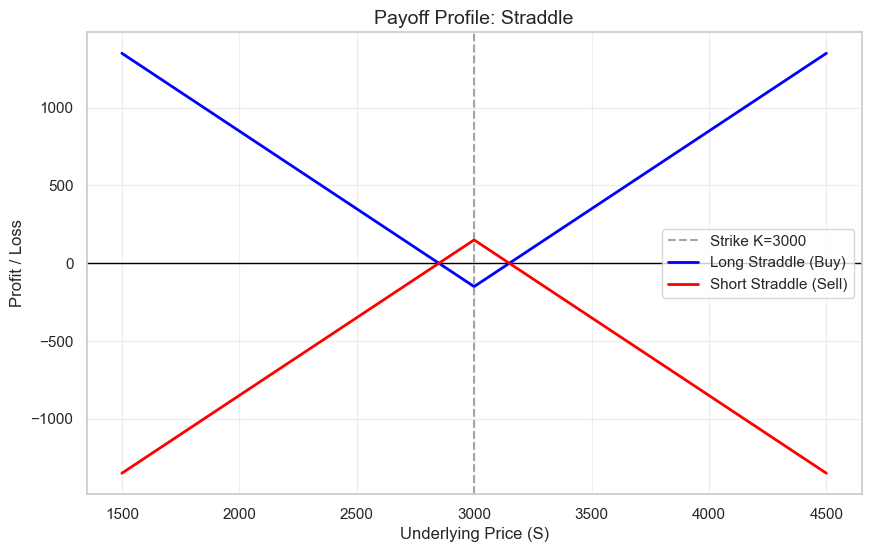

In [65]:
def plot_straddle(strike=3000, premium=150):
    """
    Plots the payoff of a Long and a Short Straddle.
    strike: Exercise price (K)
    premium: Total sum of the Call and Put premiums
    """
    # Price range around the strike (0.5x to 1.5x)
    price_range = np.linspace(strike * 0.5, strike * 1.5, 1000)
    
    # Calculate intrinsic payoffs (without premiums)
    call_payoff = np.maximum(price_range - strike, 0)
    put_payoff = np.maximum(strike - price_range, 0)
    
    # Long Straddle: (Call + Put) - Premiums paid
    long_straddle = (call_payoff + put_payoff) - premium
    
    # Short Straddle: Premiums received - (Call + Put)
    short_straddle = premium - (call_payoff + put_payoff)
    
    # Create the figure
    plt.figure(figsize=(10, 6))
    
    # Horizontal axis (Zero line)
    plt.axhline(0, color='black', linewidth=1)
    # Vertical axis (Strike price)
    plt.axvline(strike, color='gray', linestyle='--', alpha=0.7, label=f'Strike K={strike}')
    
    # Plot the curves
    plt.plot(price_range, long_straddle, label='Long Straddle (Buy)', color='blue', linewidth=2)
    plt.plot(price_range, short_straddle, label='Short Straddle (Sell)', color='red', linewidth=2)
    
    # Aesthetics
    plt.title('Payoff Profile: Straddle', fontsize=14)
    plt.xlabel('Underlying Price (S)', fontsize=12)
    plt.ylabel('Profit / Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.savefig("Images/Payoff_Profile_Straddle.png", dpi=300)
    plt.show()

# Function call
plot_straddle()

---

## 5.1.2 — Derivation of LP Delta

> ### Instructions : Students must derive the delta of the LP position - the first derivative of V_LP with respect to the ETH price p - analytically from the Uniswap V3 virtual reserve formulas. 
> ### The derivation must cover all three price cases: within range, above range, and below range.

#### Delta ($\Delta$) = $\frac{\partial V_{LP}}{\partial p}$.

* **For $p < p_a$:**
    $$\Delta = L \left( \frac{1}{\sqrt{p_a}} - \frac{1}{\sqrt{p_b}} \right)$$

* **For $p \in [p_a, p_b]$:**
    $$\Delta = L \left( \frac{1}{\sqrt{p}} - \frac{1}{\sqrt{p_b}} \right)$$

* **For $p > p_b$:**
    $$\Delta = 0$$

#### *--> NB : we see here that $\Delta$ = $\frac{\partial V_{LP}}{\partial p}$ is exactly the quantity $x(p)$.*

We'll demonstrate this after (Task 5.3) but it is interesting to see it now.

---

## 5.1.3 — Gamma

> ### Instructions : Students must derive the gamma of the LP position - the second derivative of V_LP with respect to p. 
> ### The sign and magnitude of gamma must be connected to LP position width. 

#### Gamma ($\Gamma$)

* **For $p < p_a$:**
    $$\Gamma = 0$$

* **For $p \in [p_a, p_b]$:**
    $$\Gamma = - \frac{L}{2p\sqrt{p}}$$

* **For $p > p_b$:**
    $$\Gamma = 0$$

#### --> **NB: Gamma Risk and the $L$ Factor**

The **negative sign of Gamma** indicates that **Delta is decreasing**; therefore, $V(p)$ increases at a slower and slower rate as $p$ increases within the interval $[p_a, p_b]$.

The dependence on **$L$** reveals a crucial trade-off:
* **Narrow Ranges (High $L$):** If an LP decides to invest their capital in a very narrow price range, they will earn a lot of fees because they hold a **majority position** at that price point. 
* **The Offset:** However, their **Gamma will be very high** to offset this gain. The risk is increased because if the price falls slightly from the initial price, $V(p)$ decreases much more rapidly than for a wider price range. 

**Conclusion:** since Gamma is proportional to $L$, the higher the capital efficiency ($L$), the higher the risk incurred. High $L$ translates to a much larger derivative of Delta, making the position highly sensitive to price drops.

---

# Task 5.2 — Data Collection from Hyperliquid

In [66]:
COIN = "ETH"
URL = "https://api.hyperliquid.xyz/info"

# According to question "Students must define at least a six-month historical observation window, e.g. 1 October 2025 to 31 March 2026".
start_date = datetime.datetime(2025, 10, 1, tzinfo=datetime.timezone.utc) # 1 October 2025
end_date = datetime.datetime(2026, 3, 31, 23, 59, 59, tzinfo=datetime.timezone.utc) # 31 March 2026

# print(start_date)
# print(end_date)

# As indicates here : https://hyperliquid.gitbook.io/hyperliquid-docs/for-developers/api/info-endpoint/perpetuals#retrieve-a-users-funding-history-or-non-funding-ledger-updates
# We have to use milliseconds in order to create the json taken by the POST request

start_ms = int(start_date.timestamp() * 1000)
end_ms = int(end_date.timestamp() * 1000)

# print(start_ms)
# print(end_ms)

## 5.2.1 Hourly Price Candles

> ### Instructions : Students must collect hourly OHLCV candles for the ETH perpetual on Hyperliquid for the full sixmonth study window. 
> ### The data must be saved as **perp_prices.parquet** with the candle close price used as the mark price in all subsequent hedge P&L calculations.

In [67]:
payload_candles = {
    "type": "candleSnapshot",
    "req": {
        "coin": COIN,
        "interval": "1h",
        "startTime": start_ms,
        "endTime": end_ms
    }
}

response = requests.post(URL, json=payload_candles)
data_candles = response.json()

# Transfor into DataFrame Pandas for manipulation
df_candles = pd.DataFrame(data_candles)
df_candles = df_candles.rename(columns={
    't': 'timestamp_ms', 
    'o': 'open', 
    'h': 'high', 
    'l': 'low', 
    'c': 'close', 
    'v': 'volume'
})

# Types conversion
df_candles['timestamp_ms'] = pd.to_numeric(df_candles['timestamp_ms'])
df_candles['datetime'] = pd.to_datetime(df_candles['timestamp_ms'], unit='ms', utc=True)
cols_to_float = ['open', 'high', 'low', 'close', 'volume']
df_candles[cols_to_float] = df_candles[cols_to_float].astype(float)

df_candles.to_parquet("perp_prices.parquet", index=False)
print("File 'perp_prices.parquet' saved !")

File 'perp_prices.parquet' saved !


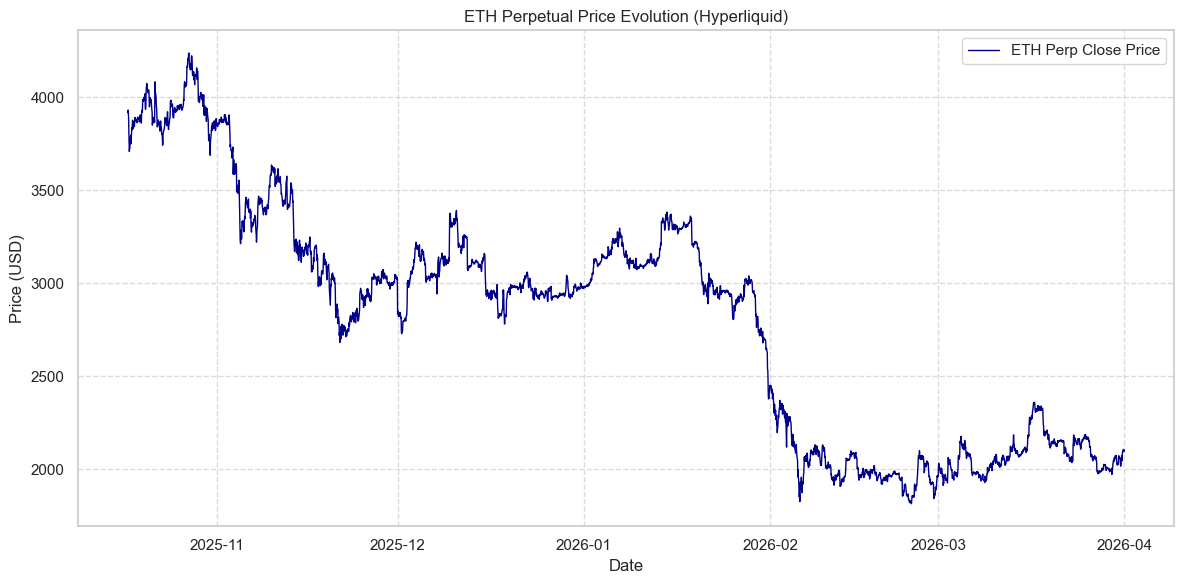

In [68]:
df_candles = pd.read_parquet("perp_prices.parquet")

plt.figure(figsize=(12, 6))
plt.plot(df_candles['datetime'], df_candles['close'], label='ETH Perp Close Price', color='darkblue', linewidth=1)

plt.title('ETH Perpetual Price Evolution (Hyperliquid)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Images/ETH_Price_Evolution.png", dpi=300)
plt.show()

### --> NB : we have only plotted the close price since over 6 months, the candlesticks would result in an indistinguishable chart.

---

## 5.2.2 Hourly Funding Rates

> ### Instructions : Students must collect all funding rate records for the ETH perpetual on Hyperliquid for the full study window.
>
> * The **fundingRate** field returned by the API is the hourly rate. 
> * The funding payment per hour for a short position of ETH futures is: 
>    $$\text{funding\_pnl} = \text{position\_size\_ETH} \times \text{oracle\_price} \times \text{funding\_rate}$$
>
> When **fundingRate** is positive (longs pay shorts), a short position receives funding. When **fundingRate** is negative, a short position pays funding.
>
> The data must be saved as **funding_rates.parquet**.

#### --> NB : Reminder of funding rate definition

Source : https://www.coinglass.com/FundingRate

"The funding rate is a fee set by cryptocurrency exchanges to maintain balance between the perpetual contract price and the underlying asset price. It applies mainly to perpetual futures contracts and acts as a mechanism for fund exchange between long and short traders. The exchange itself does not collect this fee — it serves to adjust the costs or returns of holding positions so that the contract price remains close to the spot price of the underlying asset."

In [69]:
all_funding_data = []
current_start_ms = start_ms

print("Fetching funding rates in batches...")

# Loop until we reach the targeted end date since we can only load 500 hours of funding rate data per call
while current_start_ms < end_ms:
    payload_funding = {
        "type": "fundingHistory",
        "coin": COIN,
        "startTime": current_start_ms,
        "endTime": end_ms
    }

    response_funding = requests.post(URL, json=payload_funding)
    data_funding = response_funding.json()

    # Break the loop if the API returns an empty list (ie no more data)
    if not data_funding:
        break

    all_funding_data.extend(data_funding)
    
    # Get the timestamp of the very last record in this batch
    last_timestamp = data_funding[-1]['time']
    
    # Update the start time for the next batch 
    current_start_ms = last_timestamp + 1
    
    # Small sleep to respect API rate limits
    time.sleep(0.2)

df_funding = pd.DataFrame(all_funding_data)
df_funding = df_funding.rename(columns={'time': 'timestamp_ms'})

df_funding['timestamp_ms'] = pd.to_numeric(df_funding['timestamp_ms'])
df_funding['datetime'] = pd.to_datetime(df_funding['timestamp_ms'], unit='ms', utc=True)
df_funding['fundingRate'] = df_funding['fundingRate'].astype(float)
df_funding['premium'] = df_funding['premium'].astype(float)

# Drop any accidental duplicates
df_funding = df_funding.drop_duplicates(subset=['timestamp_ms'])

df_funding.to_parquet("funding_rates.parquet", index=False)
print(f"File 'funding_rates.parquet' saved successfully with {len(df_funding)} records!")

Fetching funding rates in batches...
File 'funding_rates.parquet' saved successfully with 4368 records!


#### --> Note: Although the Hyperliquid API documentation does not explicitly state a pagination limit for the fundingHistory endpoint, empirical testing reveals a hard cap of 500 records per request. To ensure complete data extraction over the 6-month window, a robust timestamp-based pagination loop was implemented.

---

> ### Instructions : Students must produce a chart showing the hourly funding rate and cumulative funding rate over the study window alongside the ETH price, to characterise the funding environment faced by a short hedger during the chosen period.

df_merged rows: 3983


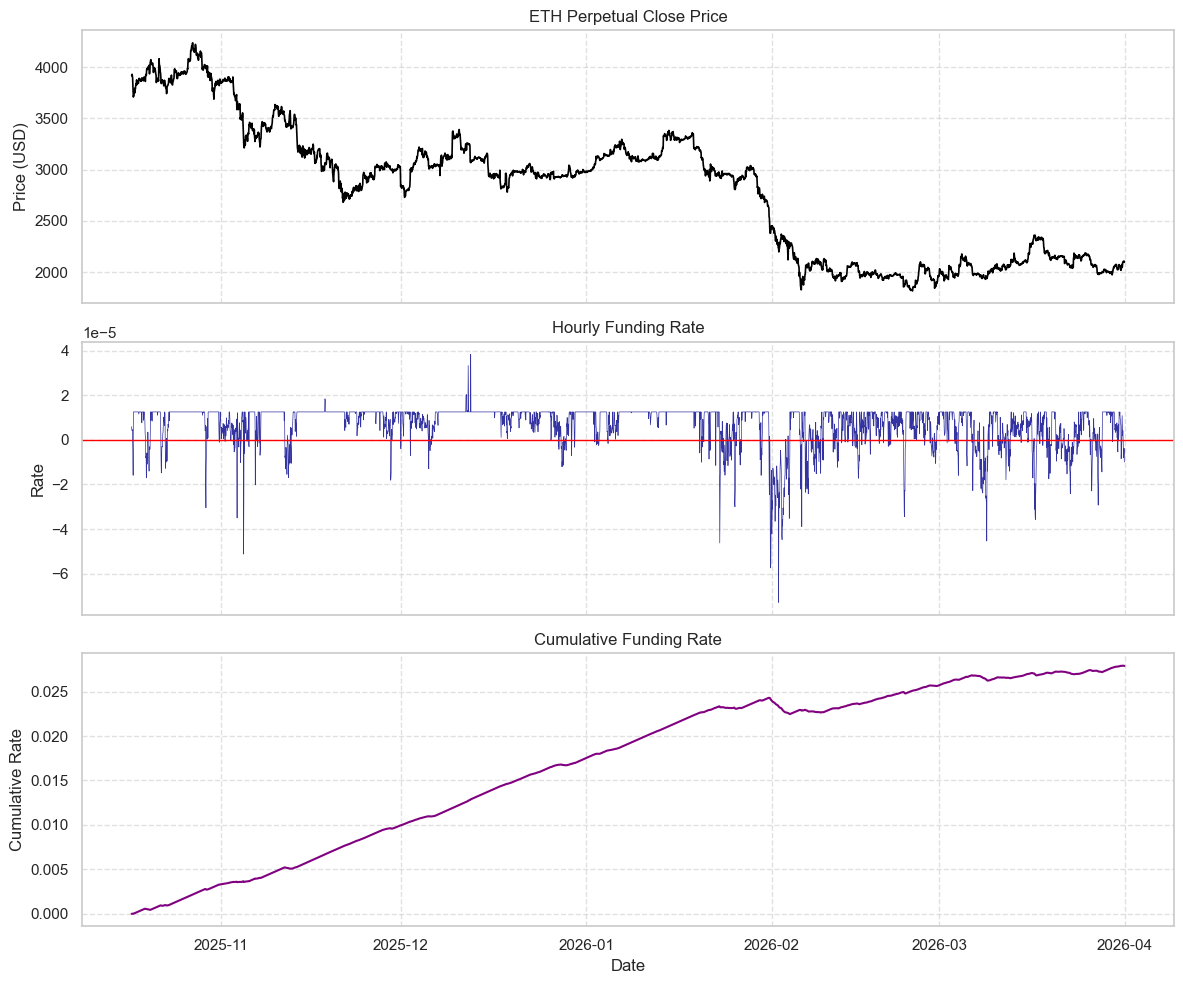

In [70]:
df_candles = pd.read_parquet("perp_prices.parquet")
df_funding = pd.read_parquet("funding_rates.parquet")

df_candles['datetime'] = df_candles['datetime'].dt.floor('h')
df_funding['datetime'] = df_funding['datetime'].dt.floor('h')

# Erase doubles
df_funding = df_funding.groupby('datetime', as_index=False)['fundingRate'].mean()

df_merged = pd.merge(
    df_candles[['datetime', 'close']],
    df_funding[['datetime', 'fundingRate']],
    on='datetime',
    how='inner'
)

print(f"df_merged rows: {len(df_merged)}")

# We use the pandas cumsum() function to accumulate the hourly rates over time
df_merged['cum_funding_rate'] = df_merged['fundingRate'].cumsum()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# ETH Price
ax1.plot(df_merged['datetime'], df_merged['close'], color='black', linewidth=1.2)
ax1.set_title('ETH Perpetual Close Price', fontsize=12)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Hourly Funding Rate
ax2.plot(df_merged['datetime'], df_merged['fundingRate'], color='darkblue', linewidth=0.5, alpha=0.8)
ax2.axhline(0, color='red', linestyle='-', linewidth=1) # Zero line for visual reference
ax2.set_title('Hourly Funding Rate', fontsize=12)
ax2.set_ylabel('Rate')
ax2.grid(True, linestyle='--', alpha=0.6)

# Cumulative Funding Rate
ax3.plot(df_merged['datetime'], df_merged['cum_funding_rate'], color='purple', linewidth=1.5)
ax3.set_title('Cumulative Funding Rate', fontsize=12)
ax3.set_xlabel('Date')
ax3.set_ylabel('Cumulative Rate')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Images/3plots.png", dpi=300)
plt.show()

---

#### --> Note : I wanted to analyse the chart during a small period of time to see the theory of funding rate.
I just asked Gemini to give me a code that emphasizes the zones were the market is bullish or bearish in order to see if the response concerning funding rate is logical.

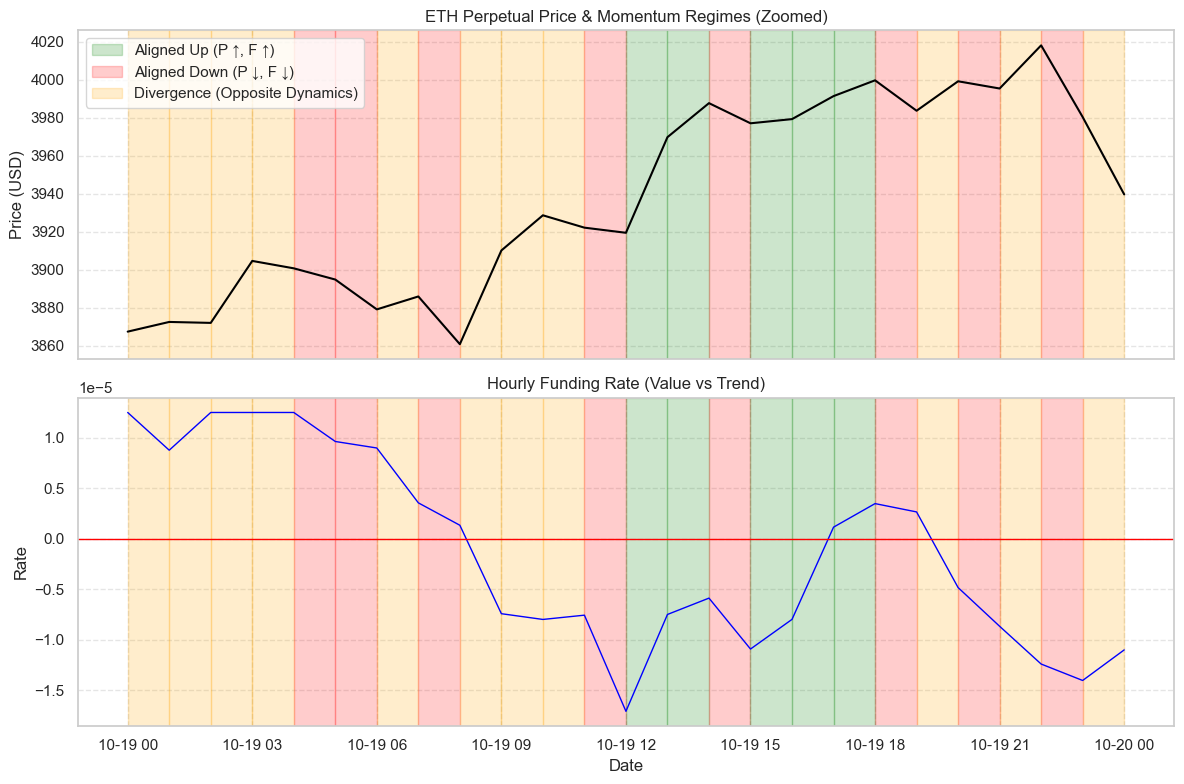

In [71]:
df = df_merged

# Slicing and sort
df_zoomed = df[(df['datetime'] >= '2025-10-19') & (df['datetime'] <= '2025-10-20')].copy()
df_zoomed = df_zoomed.sort_values('datetime').reset_index(drop=True)

df_zoomed['price_change'] = df_zoomed['close'].diff()
df_zoomed['funding_change'] = df_zoomed['fundingRate'].diff()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df_zoomed['datetime'], df_zoomed['close'], color='black')
ax1.set_title('ETH Perpetual Price & Momentum Regimes (Zoomed)', fontsize=12)
ax1.set_ylabel('Price (USD)')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_zoomed['datetime'], df_zoomed['fundingRate'], color='blue', linewidth=1)
ax2.axhline(0, color='red', linestyle='-', linewidth=1)
ax2.set_title('Hourly Funding Rate (Value vs Trend)', fontsize=12)
ax2.set_ylabel('Rate')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--', alpha=0.5)

# Apply Background Colors interval by interval
for i in range(1, len(df_zoomed)):
    t_prev = df_zoomed['datetime'].iloc[i-1]
    t_curr = df_zoomed['datetime'].iloc[i]
    
    dp = df_zoomed['price_change'].iloc[i]
    dfund = df_zoomed['funding_change'].iloc[i]
    
    if pd.isna(dp) or pd.isna(dfund):
        continue
        
    # Condition definitions
    if dp > 0 and dfund > 0:
        color = 'green'
    elif dp < 0 and dfund < 0:
        color = 'red'
    else:
        color = 'orange'
        
    ax1.axvspan(t_prev, t_curr, color=color, alpha=0.2)
    ax2.axvspan(t_prev, t_curr, color=color, alpha=0.2)

green_patch = mpatches.Patch(color='green', alpha=0.2, label='Aligned Up (P \u2191, F \u2191)')
red_patch = mpatches.Patch(color='red', alpha=0.2, label='Aligned Down (P \u2193, F \u2193)')
orange_patch = mpatches.Patch(color='orange', alpha=0.2, label='Divergence (Opposite Dynamics)')
ax1.legend(handles=[green_patch, red_patch, orange_patch], loc='upper left')

plt.tight_layout()
plt.savefig("Images/FundingRateZoomed.png", dpi=300)
plt.show()

This graph is particularly interesting as it clearly illustrates the various market scenarios:

- **RED COLOR:** The price of ETH falls: the market is bearish, prompting traders to short the market. As we saw earlier, the funding rate decreases (and tends to turn negative) because there is an excess of short positions, meaning the futures price falls below the spot price.

- **Green color:** Conversely, the market becomes bullish: traders take long positions, leading to an excess of buyers. Consequently, the funding rate must be positive, and it does indeed rise.

- **Orange color:** There are, however, special cases: such as the divergence shown in orange, where between 10-19 18 and 10-19 21, the price rises but the funding rate becomes negative. This can be explained by a spot price that rises very quickly, faster than the futures price. Because the perpetual contract lags behind and trades at a discount to the spot market, the funding rate turns negative.

---

# Task 5.3 — Delta Hedging Backtest

### --> Note : Equivalence between $\Delta_{LP}$ and Inventory $x(p)$

#### The Financial Intuition
In a liquidity pool, the directional risk (exposure to price variations) stems exclusively from the quantity of the volatile asset (ETH) we physically hold. Consequently,**Delta** is nothing more than the current **inventory**. To hedge oneself (**Delta-Neutral**), it is therefore purely logical to open a **Short** position with a size exactly equal to the number of ETH we own.

#### The Mathematical Simplification
Although the portfolio value is $V_{LP}(p) = x \cdot p + y$, the internal mechanics of the AMM dictate that $dy = -p \cdot dx$. When deriving $V_{LP}(p)$, this exchange rule cancels out the cross-terms, leading to the formal proof that:
$$\Delta_{LP} = x(p)$$

#### Impact on the Backtest (Task 5.3)
This property drastically simplifies the following code. We do not need to recalculate complex derivatives at each time step. To determine the size of the short position to open on Hyperliquid, we simply need to calculate the physical ETH reserve ($x$) at the current price $p$, reusing the direct formula from Module 4:
$$x(p) = L \cdot \left( \frac{1}{\sqrt{p}} - \frac{1}{\sqrt{p_b}} \right)$$
*(when the price is within the range).*

In [72]:
def run_hedging_simulation(df_market, lp_position, rebalance_freq_hours):
        
    current_hedge_size = 0.0
    cumulative_hedge_pnl = 0.0
    cumulative_funding_pnl = 0.0
    cumulative_fees = 0.0
    
    results = []

    # This run_hedging_simulation function is essentially based on the LP value, then we'll create a generic function that calculates it
    # Reminder : we've seen that Delta is exactly the inventory of ETH we currently have

    # According to the lecture, and we've seen it before, we have this function
    def calculate_lp_delta(price, pa, pb, L):
        if price < pa:
            delta = L * ((1.0 / np.sqrt(pa)) - (1.0 / np.sqrt(pb)))
        elif pa <= price <= pb:
            delta = L * ((1.0 / np.sqrt(price)) - (1.0 / np.sqrt(pb)))
        else:
            delta = 0.0
        return delta

    for i in range(len(df_market)):
        current_price = df_market['close'].iloc[i]
        funding_rate = df_market['fundingRate'].iloc[i]
        
        # Calculate P&L generated since the LAST hour (worst case of our frequencies)
        if i > 0:
            prev_price = df_market['close'].iloc[i-1]

            # Instructions : "A short position gains when the ETH price falls and loses when it rises"
            step_hedge_pnl = current_hedge_size * (prev_price - current_price) # "The hedge is held static between rebalancing times"

            # Instructions : positive when fundingRate > 0 (short receives), negative when fundingRate < 0 (short pays) 
            # but then it is exactly the sign of funding_rate since current_hedge_size and current_price are positive
            step_funding_pnl = current_hedge_size * current_price * funding_rate
            
            cumulative_hedge_pnl += step_hedge_pnl
            cumulative_funding_pnl += step_funding_pnl

        # Rebalancing Logic
        step_fee = 0.0
        # Check if current hour index is a multiple of our rebalancing frequency
        if i % rebalance_freq_hours == 0:
            target_delta = calculate_lp_delta(current_price, lp_position['pa'], lp_position['pb'], lp_position['L'])
            target_hedge_size = abs(target_delta)
            
            # Calculate the amount we actually need to trade on Hyperliquid
            trade_amount_eth = abs(target_hedge_size - current_hedge_size)
            step_fee = trade_amount_eth * current_price * 0.00045
            cumulative_fees += step_fee
            
            current_hedge_size = target_hedge_size

        # Others metrics
        hodl_value = lp_position['x0'] * current_price + lp_position['y0']

        if current_price < lp_position['pa']:
            v_lp = current_price * lp_position['L'] * (1/np.sqrt(lp_position['pa']) - 1/np.sqrt(lp_position['pb']))
        elif current_price > lp_position['pb']:
            v_lp = lp_position['L'] * (np.sqrt(lp_position['pb']) - np.sqrt(lp_position['pa']))
        else:
            v_lp = lp_position['L'] * (2*np.sqrt(current_price) - current_price/np.sqrt(lp_position['pb']) - np.sqrt(lp_position['pa']))

        gross_il = hodl_value - v_lp
        net_hedge_pnl = cumulative_hedge_pnl + cumulative_funding_pnl - cumulative_fees
        residual_il = gross_il - net_hedge_pnl

        results.append({
            'datetime': df_market['datetime'].iloc[i],
            'ETH price': current_price,
            'hedge_size': current_hedge_size,
            'cumulative_hedge_pnl': cumulative_hedge_pnl,
            'cumulative_funding_pnl': cumulative_funding_pnl,
            'cumulative_fees': cumulative_fees,
            'gross_il': gross_il,
            'net_hedge_pnl': net_hedge_pnl,
            'residual_IL': residual_il 
        })

    return pd.DataFrame(results)

### Reminder of the results from Module 4

#### Summary of Liquidity Positions (USDC/WETH)

| Position | Description | tick_lower | tick_upper | Price lower | Price upper | L | x0 (WETH) | y0 (USDC) | Initial value (USD) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **P1** | +-0.1% ultra-narrow | 193010 | 193040 | 4138.1 | 4.150500e+03 | 1.0359e+18 | 9.587416 | 60254.76 | 100000.0 |
| **P2** | +-0.5% narrow | 192970 | 193080 | 4121.6 | 4.167100e+03 | 2.8279e+17 | 11.387132 | 52793.93 | 100000.0 |
| **P3** | +-2% medium | 192820 | 193230 | 4060.2 | 4.230100e+03 | 7.6155e+16 | 11.880948 | 50746.78 | 100000.0 |
| **P4** | +-10% wide | 192060 | 194080 | 3729.4 | 4.564100e+03 | 1.5771e+16 | 11.501304 | 52320.62 | 100000.0 |
| **P5** | full range | -887270 | 887270 | 0.0 | 3.401887e+50 | 7.7657e+14 | 12.061088 | 50000.00 | 100000.0 |

### Liquidity Unit Conversion

Before running the dynamic Delta hedging simulation, a critical data adjustments is required to bridge the continuous Automated Market Maker (AMM) environment (Module 4) with the discrete perpetual futures environment (Module 5).

The liquidity values ($L$) imported from the Module 4 analytics were calculated using the native raw decimals of the Ethereum tokens. Since USDC operates with $10^6$ decimals and WETH with $10^{18}$ decimals, the raw liquidity parameter is derived as follows:
$$L_{raw} = \sqrt{(X_{module5} \cdot 10^{18}) \cdot (Y_{module5} \cdot 10^6)}$$
$$L_{raw} = \sqrt{X_{module5} \cdot Y_{module5} \cdot 10^{24}} = L_{module5} \cdot 10^{12}$$

Using $L_{raw}$ directly in our theoretical Delta formula ($\Delta_{LP} = L \left( \frac{1}{\sqrt{p}} - \frac{1}{\sqrt{p_b}} \right)$) alongside human-readable prices would yield astronomically incorrect ETH exposure. Therefore, all $L$ parameters from Module 4 were explicitly divided by $10^{12}$ prior to the simulation to ensure the short hedge sizes represent realistic WETH amounts.

#### --> NB : I've noticed that the first value P0 isn't the same than in module 4.

In [73]:
# P0 is the ETH price at t=0 of your study window
P0 = df_merged['close'].iloc[0]
print(P0)
print(df_merged['datetime'].iloc[0])

3917.7
2025-10-17 01:00:00+00:00


#### Let see what happens if we keep the actual values from module 4 : 

In [74]:
# P0 is the ETH price at t=0 of your study window
P0 = df_merged['close'].iloc[0]

positions = [
    {
        'name': 'P1',
        'pa': 4138.1,
        'pb': 4150.5,
        'L': 1.0359e18 / 1e12,
        'x0': 9.587416,
        'y0': 60254.76
    },
    {
        'name': 'P2',
        'pa': 4121.6,
        'pb': 4167.1,
        'L': 2.8279e17 / 1e12,
        'x0': 11.387132,
        'y0': 52793.93
    },
    {
        'name': 'P3',
        'pa': 4060.2,
        'pb': 4230.1,
        'L': 7.6155e16 / 1e12,
        'x0': 11.880948,
        'y0': 50746.78
    },
    {
        'name': 'P4',
        'pa': 3729.4,
        'pb': 4564.1,
        'L': 1.5771e16 / 1e12,
        'x0': 11.501304,
        'y0': 52320.62
    },
    {
        'name': 'P5',
        'pa': 0.0001,           # a value close to zero
        'pb': float('inf'),     
        'L': 7.7657e14 / 1e12,
        'x0': 12.061088,
        'y0': 50000.00
    }
]

In [75]:
P0_actual = df_merged['close'].iloc[0]  # 4466
print(f"P0 réel: {P0_actual}")

for pos in positions:
    in_range = pos['pa'] <= P0_actual <= pos['pb']
    print(f"{pos['name']}: pa={pos['pa']:.0f}, pb={pos['pb']:.0f}, P0 in range: {in_range}")

P0 réel: 3917.7
P1: pa=4138, pb=4150, P0 in range: False
P2: pa=4122, pb=4167, P0 in range: False
P3: pa=4060, pb=4230, P0 in range: False
P4: pa=3729, pb=4564, P0 in range: True
P5: pa=0, pb=inf, P0 in range: True


### --> The issue:
The positions defined in Module 4 were centered around an entry price of approximately $4,103. However, the market data used for this backtest starts at a price of $4,524.5 **(this value can be modified if we rerun the code entirely because of the API - but the idea stays the same)**.  

#### Impact on Results:
- **Out-of-Range at Entry:** As demonstrated by the diagnostic check, positions P1, P2, and P3 are already "out-of-range" at $t=0$ because their upper bounds ($p_b$) are lower than the actual starting price of $4,524.5.
- **Incorrect Delta Calculation:** Because these positions start out-of-range (above the range), the calculated LP Delta is 0. Consequently, the short hedge is not correctly sized or initialized for the actual price movement.  
- **Hedge Overcompensation:** The ETH price fell from $4,524 to approximately $2,104 during the study window. The short position gained significantly on this entire $2,420 drop. However, the Impermanent Loss (IL) is calculated based on bounds centered at $4,103. This mismatch results in a Net Hedge PnL (~$41k) that far exceeds the Gross IL (~$24k), leading to a misleading negative Residual IL of approximately -$17k.  

#### Conclusion:
To ensure a valid backtest, the position boundaries ($p_a$ and $p_b$) must be recalibrated to be centered on the actual $P_0$ of the study window as per the project requirements for Task 4.1. Using the static values from a different time-frame results in a "broken" hedge that does not accurately reflect the delta-neutral strategy intended.  

In [76]:
TICK_SPACE = 10
MIN_TICK   = -887270
MAX_TICK   =  887270
NOTIONAL   = 100_000.0

def tick_to_price(tick):
    return 1e12 / (1.0001 ** tick)  # "human price" USDC/WETH

# Entry price = first tick of df_merged
entry_price = df_merged['close'].iloc[0]
entry_tick  = round(math.log(1e12 / entry_price) / math.log(1.0001))

print(f"Entry price: {entry_price:.2f}, entry_tick: {entry_tick}")

POSITION_DEFS = [
    ("P1", 0.001),
    ("P2", 0.005),
    ("P3", 0.02),
    ("P4", 0.10),
    ("P5", None),
]

positions = []

for name, pct in POSITION_DEFS:
    if pct is None:
        pa, pb = 1e-8, 1e8
    else:
        pa = entry_price * (1 - pct)
        pb = entry_price * (1 + pct)

    p = entry_price
    if p < pa:
        v_per_L = p * (1/math.sqrt(pa) - 1/math.sqrt(pb))
    elif p > pb:
        v_per_L = math.sqrt(pb) - math.sqrt(pa)
    else:
        v_per_L = 2*math.sqrt(p) - p/math.sqrt(pb) - math.sqrt(pa)

    L  = NOTIONAL / v_per_L
    x0 = L * (1/math.sqrt(p) - 1/math.sqrt(pb)) if pa <= p <= pb else (L * (1/math.sqrt(pa) - 1/math.sqrt(pb)) if p < pa else 0)
    y0 = NOTIONAL - x0 * p

    positions.append({'name': name, 'pa': pa, 'pb': pb, 'L': L, 'x0': x0, 'y0': y0})
    print(f"{name}: pa={pa:.1f}, pb={pb:.1f}, L={L:.2f}, x0={x0:.4f} ETH, y0={y0:.2f} USD")

frequencies = [1, 4, 24]
all_results = []

for pos in positions:
    for freq in frequencies:
        df_res = run_hedging_simulation(df_merged, pos, freq)
        df_res['position_type'] = pos['name']
        df_res['rebalance_freq'] = freq
        all_results.append(df_res)

final_df = pd.concat(all_results, ignore_index=True)
final_df.to_parquet("hedge_results.parquet")

Entry price: 3917.70, entry_tick: 193587
P1: pa=3913.8, pb=3921.6, L=1598059.10, x0=12.7562 ETH, y0=50024.99 USD
P2: pa=3898.1, pb=3937.3, L=319928.96, x0=12.7307 ETH, y0=50124.84 USD
P3: pa=3839.3, pb=3996.1, L=80272.48, x0=12.6356 ETH, y0=50497.54 USD
P4: pa=3525.9, pb=4309.5, L=16326.96, x0=12.1393 ETH, y0=52442.05 USD
P5: pa=0.0, pb=100000000.0, L=801.34, x0=12.7225 ETH, y0=50156.93 USD


We can verify that we are now in range :

In [77]:
P0_actual = df_merged['close'].iloc[0]
print(f"P0 réel: {P0_actual}")

for pos in positions:
    in_range = pos['pa'] <= P0_actual <= pos['pb']
    print(f"{pos['name']}: pa={pos['pa']:.0f}, pb={pos['pb']:.0f}, P0 in range: {in_range}")

P0 réel: 3917.7
P1: pa=3914, pb=3922, P0 in range: True
P2: pa=3898, pb=3937, P0 in range: True
P3: pa=3839, pb=3996, P0 in range: True
P4: pa=3526, pb=4309, P0 in range: True
P5: pa=0, pb=100000000, P0 in range: True


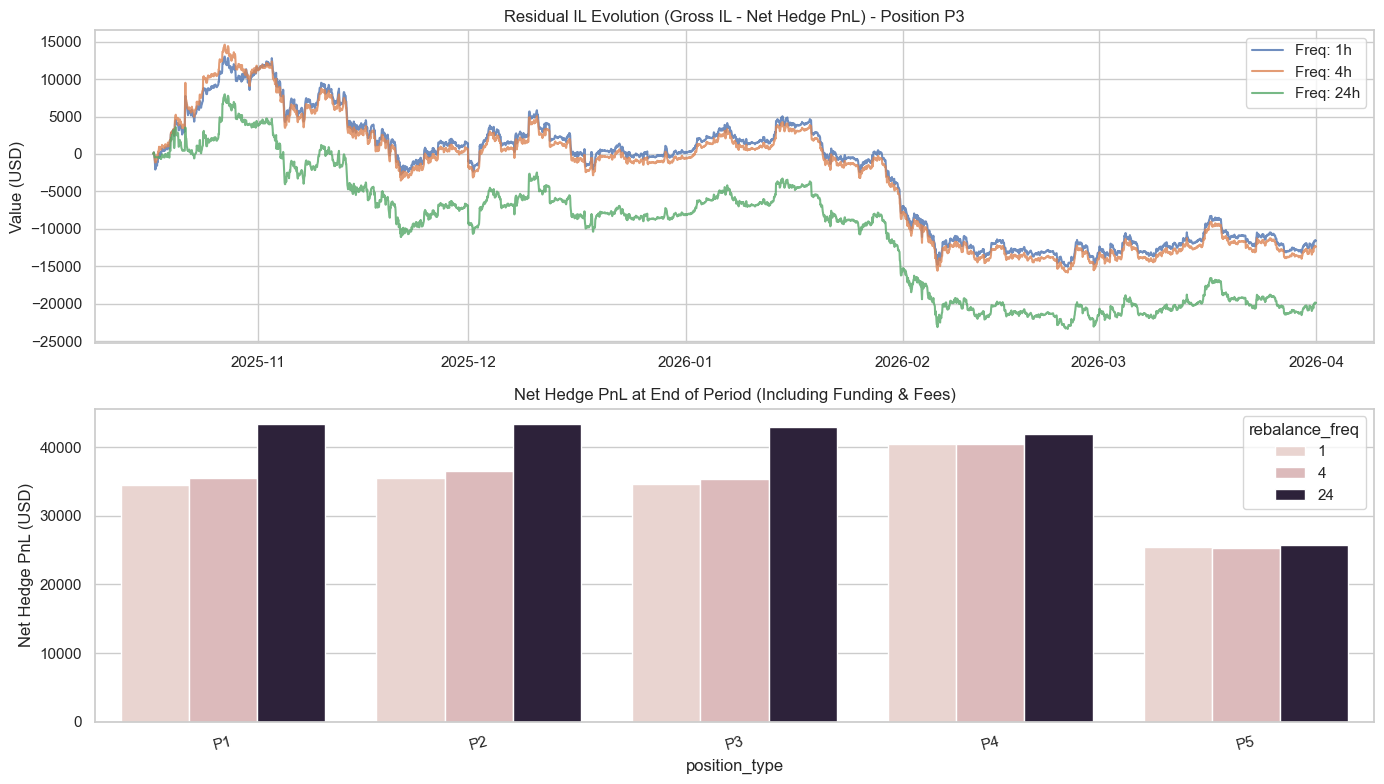

In [78]:
df = pd.read_parquet("hedge_results.parquet")
df['datetime'] = pd.to_datetime(df['datetime'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Residual IL Evolution for a specific position
subset = df[df['position_type'] == 'P3']

plt.subplot(2, 1, 1)
for freq in subset['rebalance_freq'].unique():
    data_freq = subset[subset['rebalance_freq'] == freq]
    
    plt.plot(data_freq['datetime'], data_freq['residual_IL'], label=f'Freq: {freq}h', alpha=0.8)

plt.title("Residual IL Evolution (Gross IL - Net Hedge PnL) - Position P3")
plt.ylabel("Value (USD)")
plt.legend()

# Final Net Hedge PnL Comparison by Position and Frequency
final_metrics = df.groupby(['position_type', 'rebalance_freq']).last().reset_index()

plt.subplot(2, 1, 2)
sns.barplot(data=final_metrics, x='position_type', y='net_hedge_pnl', hue='rebalance_freq')
plt.title("Net Hedge PnL at End of Period (Including Funding & Fees)")
plt.ylabel("Net Hedge PnL (USD)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("Images/Residual IL Evolution.png", dpi=300)
plt.show()

In [79]:
df = pd.read_parquet("hedge_results.parquet")

p3_1h = df[(df['position_type']=='P3') & (df['rebalance_freq']==1)]
last = p3_1h.iloc[-1]
print(f"cumulative_hedge_pnl:   {last['cumulative_hedge_pnl']:.0f}")
print(f"cumulative_funding_pnl: {last['cumulative_funding_pnl']:.0f}")
print(f"cumulative_fees:        {last['cumulative_fees']:.0f}")
print(f"net_hedge_pnl:          {last['net_hedge_pnl']:.0f}")
print(f"\nPrix initial: {p3_1h.iloc[0]['ETH price']:.0f}")
print(f"Prix final:   {p3_1h.iloc[-1]['ETH price']:.0f}")
print(f"\nHedge size moyen: {p3_1h['hedge_size'].mean():.4f} ETH")
print(f"Hedge size max:   {p3_1h['hedge_size'].max():.4f} ETH")

cumulative_hedge_pnl:   33895
cumulative_funding_pnl: 1986
cumulative_fees:        1224
net_hedge_pnl:          34656

Prix initial: 3918
Prix final:   2104

Hedge size moyen: 24.3705 ETH
Hedge size max:   25.6560 ETH


---

# Task 5.4 — Limitations and Extensions

> #### Instructions : Students must write a critical discussion addressing the following four limitations of the deltahedging strategy:
> #### • Residual gamma risk
> #### • Funding rate risk
> #### • Minimum LP position size for which the delta-hedging strategy is economically viable
> #### • Alternatives of hedging via options and what necessary assumptions to make this effective (e.g. options availability and liquidity, etc.)



### Residual Gamma Risk

The LP position has a continuously varying, negative Gamma, whereas the linear perp hedge has, by definition, zero Gamma.

The gap between the drifting LP Delta and the fixed hedge between each rebalancings creates a **residual Gamma risk** that grows with price volatility and the time interval (1h, 4h, 24h). The results clearly illustrate this dynamic:

* **1h and 4h frequencies:** Limit the drift, with the residual IL heavily fluctuating between +$15,000 and -$15,000;
* **24h frequency:** Drifts severely into negative territory, dropping as low as -$25,000 due to the compounding effect of leaving large intra-day price moves unhedged.

Although narrower positions (like P1, P2) are theoretically more exposed to this risk due to their higher liquidity concentration (`L`), they exit their range almost immediately in practice. Therefore, residual IL depends more on the time spent in-range than solely on the range width.

### Funding Rate Risk

Because the dynamic hedge alternates between short and long positions depending on price deviation, it avoids the structural funding bias of a permanent short hedge.

However, the ETH perp market experienced predominantly positive funding rates between October 2025 and March 2026. This means the hedge benefited from receiving funding during its short phases, artificially boosting profits. In a prolonged bear market with negative funding rates, the short side of the hedge would pay rather than receive, which would inevitably compress the net PnL.

### Transaction Costs vs. Optimal Frequency

The 0.045% taker fee applied at every rebalancing heavily penalizes high-frequency execution.

* **Concentrated positions (P1, P2, P3):** as we can see on the graph, the 24h frequency significantly outperforms. The compounding costs of hourly rebalancing (fees and funding) destroy profitability, far outweighing the benefits of a tighter hedge.
* **Full-range position (P5):** Rebalancing frequency has virtually no impact. The range is so wide that adjustment trades are rarely triggered, rendering high-frequency execution unnecessary.

**Conclusion:** This strategy requires a **substantial minimum viable scale**. If the fee drag is already significant on a $100k position at a 1h frequency, it would completely wipe out any hedging benefits on a smaller portfolio (e.g., $10k).

### 4. The Theoretical Alternative: Options

Perps successfully hedge first-order exposure (Delta) but leave second-order exposure (Gamma) unhedged. Since the LP is structurally short Gamma, the ideal theoretical instrument is a **long Gamma position** - such as buying options symmetrically (e.g., a Straddle or Strangle - we've seen a straddle before). This would hedge Impermanent Loss without requiring continuous rebalancing.

But after asking if it is possible to Gemini, it seems complicated in practice since the crypto options ecosystem presents three major obstacles to this approach:

* **Fixed Expiries:** Traditional options require frequent, costly roll-overs that do not align with the continuous, path-dependent payoff of an LP position.
* **Theta (Time Decay):** The time cost of holding long options must be offset by LP fee income, which is never guaranteed—especially if the price drops out of range.
* **Bid-Ask Spreads:** Out-of-the-money (OTM) crypto options suffer from low liquidity and wide spreads, making precise replication economically unviable for anything below an institutional scale.